In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

Load Dataset

In [3]:

df = pd.read_csv("Users.csv")

df.head()


,User_id,Name,Age,Gender,Marital Status,Occupation
0,1,Claire Ferguson,20,Female,Single,Student
1,2,Jennifer Young,24,Female,Single,Student
2,3,Jermaine Roberson,22,Male,Single,Student
3,4,Rachel Carpenter,22,Female,Single,Student
4,5,Shawn Parker,22,Male,Single,Student


Basic Overview

In [4]:
df.shape          # rows, columns


(100000, 6)

In [5]:
df.info()         # datatypes, null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   User_id         100000 non-null  int64 
 1   Name            100000 non-null  object
 2   Age             100000 non-null  int64 
 3   Gender          100000 non-null  object
 4   Marital Status  100000 non-null  object
 5   Occupation      100000 non-null  object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB


In [6]:
df.columns        # column names


Index(['User_id', 'Name', 'Age', 'Gender', 'Marital Status', 'Occupation'], dtype='object')

Statistical Summary

In [7]:
df.describe()

,User_id,Age
count,100000.000000,100000.000000
mean,50000.500000,24.628580
std,28867.657797,2.971743
min,1.000000,18.000000
25%,25000.750000,23.000000
50%,50000.500000,24.000000
75%,75000.250000,26.000000
max,100000.000000,33.000000


Missing Values

In [8]:
df.isnull().sum()

User_id           0
Name              0
Age               0
Gender            0
Marital Status    0
Occupation        0
dtype: int64

Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

User_id            int64
Name              object
Age                int64
Gender            object
Marital Status    object
Occupation        object
dtype: object

Separate Numerical & Categorical Columns

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['User_id', 'Age'], dtype='object')
Categorical Columns: Index(['Name', 'Gender', 'Marital Status', 'Occupation'], dtype='object')


Univariate Analysis

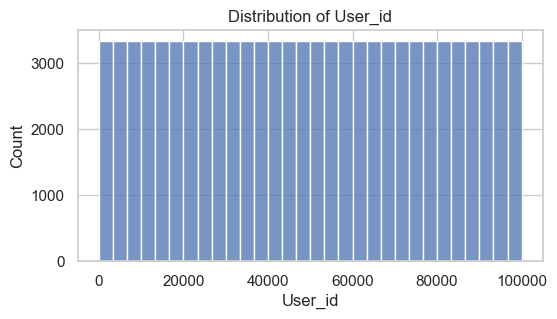

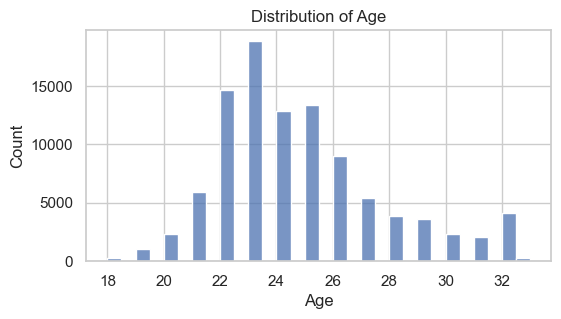

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


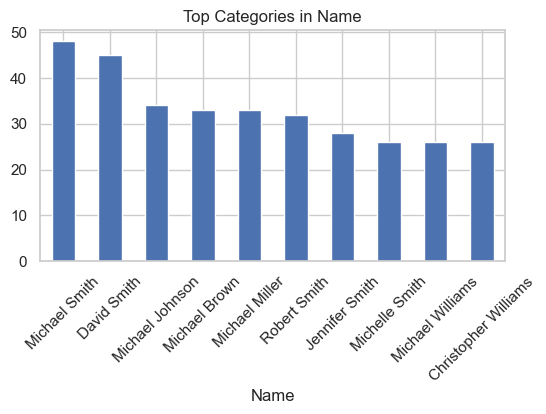

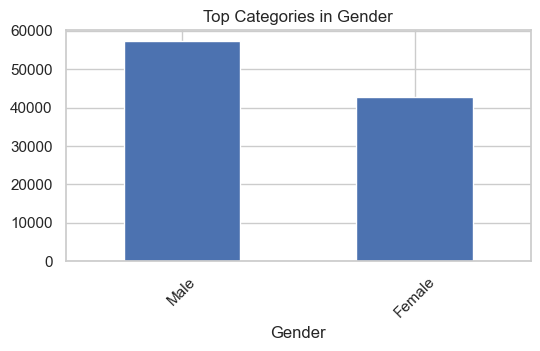

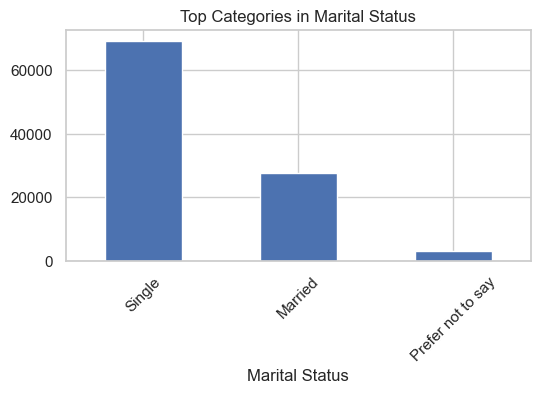

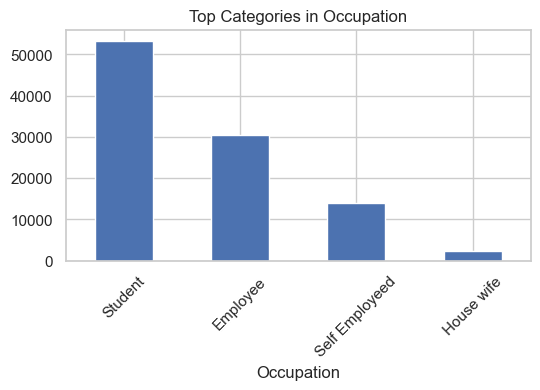

In [13]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()


Bivariate Analysis

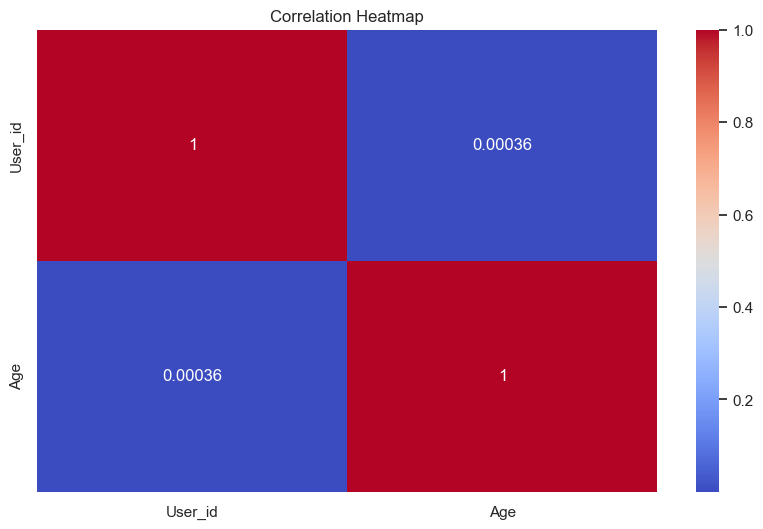

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Outlier Detection

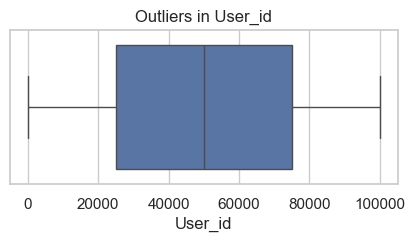

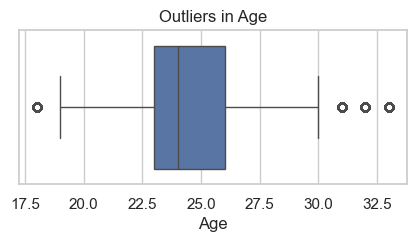

In [15]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()
